In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Terzo anno/Tirocinio/Python/Mixed data- Legnaro/File uniti/File/TF_filtrato.csv')
print(df)

         m_TF_0    timestamp0    m_TF_1  timestamp1
0     -0.462135  1.750166e+09  0.347079  1750165544
1      0.961260  1.750166e+09  0.186966  1750165544
2     -0.359476  1.750166e+09 -0.245998  1750165545
3     -0.806044  1.750166e+09  0.414493  1750165545
4      0.050677  1.750166e+09 -0.531499  1750165546
...         ...           ...       ...         ...
19808       NaN           NaN  0.003266  1750487718
19809       NaN           NaN -0.677170  1750487718
19810       NaN           NaN  1.514449  1750487718
19811       NaN           NaN  0.233914  1750487718
19812       NaN           NaN -0.811337  1750487719

[19813 rows x 4 columns]


In [3]:
import numpy as np

# Dati di partenza
mTF0 = np.array(df.m_TF_0)
mTF1 = np.array(df.m_TF_1)
tempo0 = np.array(df.timestamp0)
tempo1 = np.array(df.timestamp1)

# Conversione timestamp in datetime
t0 = pd.to_datetime(tempo0, unit='s')
t1 = pd.to_datetime(tempo1, unit='s')

# Calcolo angoli (in gradi)
mtf0_atg = np.arctan(mTF0)
mtf0_arctg = np.degrees(mtf0_atg)
teta_tf0 = 90 - mtf0_arctg

mtf1_atg = np.arctan(mTF1)
mtf1_arctg = np.degrees(mtf1_atg)
teta_tf1 = 90 - mtf1_arctg

In [4]:
# Heatmap TF: camera verticale

/tmp/ipython-input-3086446909.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_teta_cleaned['datetime'] = df_teta_cleaned['datetime'].dt.floor('H')
/tmp/ipython-input-3086446909.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data_teta = df_teta_cleaned.pivot_table(


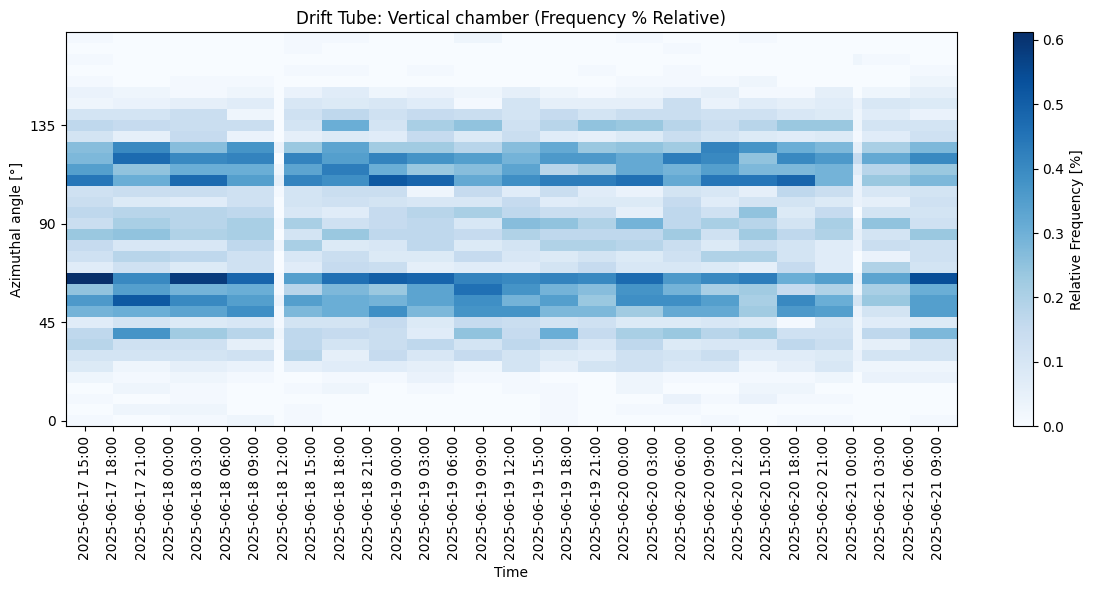

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

# Crea il DataFrame per teta_sl0
data = {'datetime': t0, 'teta_tf0': teta_tf0}
df_teta = pd.DataFrame(data)
df_teta_cleaned = df_teta.dropna(subset=['datetime', 'teta_tf0']).copy()

# Calcola i bin (ampiezza 5)
min_val = np.floor(df_teta_cleaned['teta_tf0'].min() / 10) * 10
max_val = np.ceil(df_teta_cleaned['teta_tf0'].max() / 10) * 10
bin_edges = np.arange(min_val, max_val + 5, 5)  # aggiungi +5 per includere l'ultimo bin

# Assegna i valori ai bin
df_teta_cleaned['teta_tf0_bin'] = pd.cut(df_teta_cleaned['teta_tf0'], bins=bin_edges)

df_teta_cleaned['datetime'] = df_teta_cleaned['datetime'].dt.floor('H')

# Crea la tabella pivot per la heatmap
heatmap_data_teta = df_teta_cleaned.pivot_table(
    index='teta_tf0_bin',
    columns='datetime',
    values='teta_tf0',
    aggfunc='count',
    fill_value=0
)

# Calcolo della frequenza relativa percentuale globale
total_count = heatmap_data_teta.values.sum()
heatmap_percent = (heatmap_data_teta / total_count) * 100

# Meshgrid
x = mdates.date2num(heatmap_percent.columns.to_pydatetime())
if len(x) > 1:
    delta = x[-1] - x[-2]
else:
    delta = 1
x = np.append(x, x[-1] + delta)
y = np.arange(len(heatmap_percent.index) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.xlabel("Time")
plt.ylabel("Azimuthal angle [°]")
plt.title("Drift Tube: Vertical chamber (Frequency % Relative)")

# Asse X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
plt.xticks(rotation=90)

# Etichette Y per intervalli angolari desiderati (0°, 45°, 90°, ...)
desired_labels = [0, 45, 90, 135, 180]
yticks = []
yticklabels = []

for i, interval in enumerate(heatmap_percent.index):
    left_val = int(interval.left)
    if left_val in desired_labels:
        yticks.append(i + 0.5)
        yticklabels.append(str(left_val))

plt.yticks(ticks=yticks, labels=yticklabels, fontsize=10)

# Heatmap
pc = plt.pcolormesh(x, y, heatmap_percent.values, cmap='Blues', shading='auto')
plt.colorbar(pc, label='Relative Frequency [%]')
plt.tight_layout()
plt.show()


In [6]:
#Heatmap: SL, camera orizzontale

/tmp/ipython-input-1798880547.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_teta_cleaned['datetime'] = df_teta_cleaned['datetime'].dt.floor('H')
/tmp/ipython-input-1798880547.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data_teta = df_teta_cleaned.pivot_table(


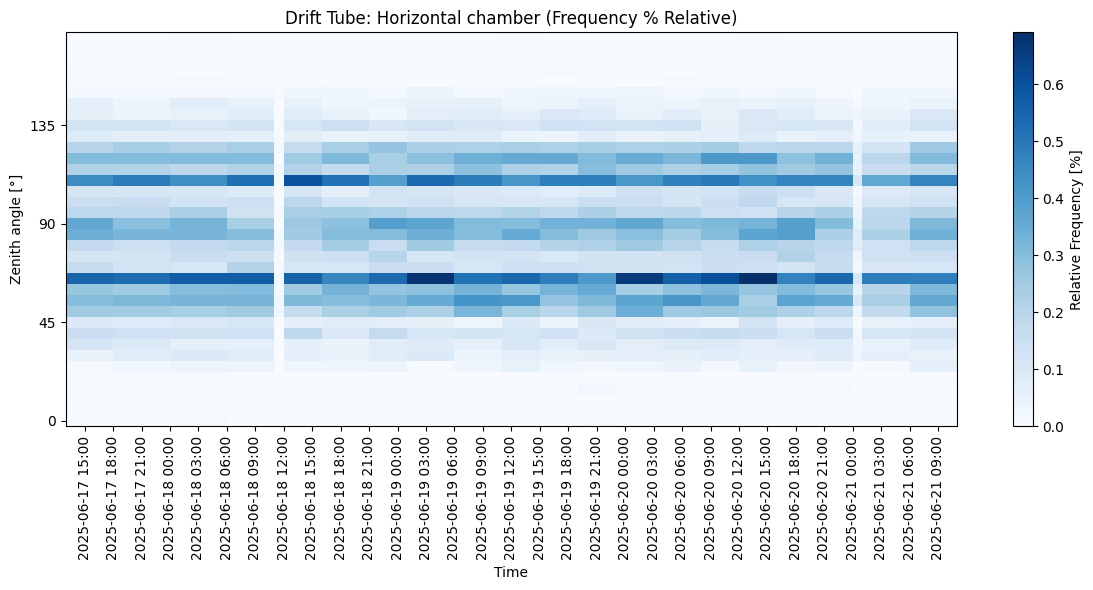

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

# Crea il DataFrame per teta_sl0
data = {'datetime': t1, 'teta_tf1': teta_tf1}
df_teta = pd.DataFrame(data)
df_teta_cleaned = df_teta.dropna(subset=['datetime', 'teta_tf1']).copy()

# Calcola i bin (ampiezza 5)
min_val = np.floor(df_teta_cleaned['teta_tf1'].min() / 10) * 10
max_val = np.ceil(df_teta_cleaned['teta_tf1'].max() / 10) * 10
bin_edges = np.arange(min_val, max_val + 5, 5)  # aggiungi +5 per includere l'ultimo bin

# Assegna i valori ai bin
df_teta_cleaned['teta_tf1_bin'] = pd.cut(df_teta_cleaned['teta_tf1'], bins=bin_edges)

df_teta_cleaned['datetime'] = df_teta_cleaned['datetime'].dt.floor('H')

# Crea la tabella pivot per la heatmap
heatmap_data_teta = df_teta_cleaned.pivot_table(
    index='teta_tf1_bin',
    columns='datetime',
    values='teta_tf1',
    aggfunc='count',
    fill_value=0
)

# Calcolo della frequenza relativa percentuale globale
total_count = heatmap_data_teta.values.sum()
heatmap_percent = (heatmap_data_teta / total_count) * 100

# Meshgrid
x = mdates.date2num(heatmap_percent.columns.to_pydatetime())
if len(x) > 1:
    delta = x[-1] - x[-2]
else:
    delta = 1
x = np.append(x, x[-1] + delta)
y = np.arange(len(heatmap_percent.index) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.xlabel("Time")
plt.ylabel("Zenith angle [°]")
plt.title("Drift Tube: Horizontal chamber (Frequency % Relative)")

# Asse X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
plt.xticks(rotation=90)

# Etichette Y per intervalli angolari desiderati (0°, 45°, 90°, ...)
desired_labels = [0, 45, 90, 135, 180]
yticks = []
yticklabels = []

for i, interval in enumerate(heatmap_percent.index):
    left_val = int(interval.left)
    if left_val in desired_labels:
        yticks.append(i + 0.5)
        yticklabels.append(str(left_val))

plt.yticks(ticks=yticks, labels=yticklabels, fontsize=10)

# Heatmap
pc = plt.pcolormesh(x, y, heatmap_percent.values, cmap='Blues', shading='auto')
plt.colorbar(pc, label='Relative Frequency [%]')
plt.tight_layout()
plt.show()